In [37]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Train:Val:Test split = 6:2:2 for the ETT datasets and 7:1:2 for Weather, Electricity, and Exchange Rate.
electricity = pd.read_csv('../datasets/electricity/electricity.csv')
weather = pd.read_csv('../datasets/weather/weather.csv')
exchange_rate = pd.read_csv('../datasets/exchange_rate/exchange_rate.csv')
etth1 = pd.read_csv('../datasets/ETT-small/ETTh1.csv')
etth2 = pd.read_csv('../datasets/ETT-small/ETTh2.csv')
ettm1 = pd.read_csv('../datasets/ETT-small/ETTm1.csv')
ettm2 = pd.read_csv('../datasets/ETT-small/ETTm2.csv')

electricity_N = len(electricity)
electricity_train = electricity.iloc[:int(0.7*electricity_N)]
electricity_test = electricity.iloc[-int(0.2*electricity_N):]


In [90]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean
import random
import matplotlib.colors as mcolors

# 미리 정의된 색상 옵션
COLOR_OPTIONS = {
    'red': '#FF0000',
    'blue': '#0000FF',
    'green': '#00FF00',
    'orange': '#FFA500',
    'purple': '#800080',
    'cyan': '#00FFFF',
    'magenta': '#FF00FF',
    'yellow': '#FFFF00',
    'pink': '#FFC0CB',
    'brown': '#A52A2A',
    'navy': '#000080',
    'teal': '#008080',
    'lime': '#00FF00',
    'maroon': '#800000',
    'olive': '#808000',
}

def lighten_color(color, lightness=50):
    """
    색상을 연하게 만드는 함수
    
    Parameters:
    -----------
    color : str
        색상 (matplotlib 색상 이름, hex 코드, 또는 COLOR_OPTIONS의 키)
    lightness : int
        연한 정도 (0~100, 0이면 원래 색, 100이면 가장 연하게)
    
    Returns:
    --------
    str
        연한 색상의 hex 코드
    """
    # 색상 이름을 hex로 변환
    if color in COLOR_OPTIONS:
        color = COLOR_OPTIONS[color]
    elif color in mcolors.CSS4_COLORS:
        color = mcolors.CSS4_COLORS[color]
    
    # hex 코드를 RGB로 변환
    if color.startswith('#'):
        rgb = tuple(int(color[i:i+2], 16) for i in (1, 3, 5))
    else:
        # matplotlib 색상 이름인 경우
        rgb = mcolors.to_rgb(color)
        rgb = tuple(int(c * 255) for c in rgb)
    
    # 연한 정도에 따라 RGB 조절 (0~100을 0~1로 변환)
    lightness_factor = lightness / 100.0
    
    # 흰색(255, 255, 255)에 가깝게 만들기
    new_rgb = tuple(int(c + (255 - c) * lightness_factor) for c in rgb)
    
    # hex 코드로 변환
    return '#{:02X}{:02X}{:02X}'.format(*new_rgb)

def retrieve_similar_segments(dataset_name, segment_length=512, k=5, var_idx=0, query_segment_idx=None, 
                              M=0, color='red', lightness=50, show_grid=False, random_seed=None):
    """
    각 데이터셋에서 TS segment를 생성하고, Test set에서 지정한 segment를 추출한 뒤,
    Train에서 가장 유사한 top k개를 찾는 함수 (univariate 처리)
    
    Parameters:
    -----------
    dataset_name : str
        데이터셋 이름 (e.g., 'ETTh1', 'electricity', 'weather', 'exchange_rate', 'ETTh2', 'ETTm1', 'ETTm2')
    segment_length : int
        TS segment의 길이 (default: 512)
    k : int
        반환할 유사한 segment의 개수 (default: 5)
    var_idx : int
        사용할 변수(channel) 인덱스 (default: 0, 첫 번째 변수)
    query_segment_idx : int, optional
        Test set에서 사용할 segment 인덱스 (default: None, 랜덤 선택)
    M : int
        지정한 색상으로 표시할 segment 개수 (나머지는 연한 색상) (default: 0)
    color : str
        색상 (default: 'red'). 사용 가능한 옵션:
        - COLOR_OPTIONS의 키: 'red', 'blue', 'green', 'orange', 'purple', 'cyan', 
          'magenta', 'yellow', 'pink', 'brown', 'navy', 'teal', 'lime', 'maroon', 'olive'
        - matplotlib 색상 이름 (e.g., 'crimson', 'steelblue')
        - hex 코드 (e.g., '#FF0000')
    lightness : int
        연한 정도 (0~100, default: 50). 0이면 원래 색상, 100이면 가장 연하게
    show_grid : bool
        Grid 표시 여부 (default: False)
    random_seed : int, optional
        query_segment_idx가 None일 때 사용할 랜덤 시드 (default: None)
    
    Returns:
    --------
    query_segment : np.ndarray
        Test set에서 추출한 query segment (univariate, shape: (segment_length,))
    similar_segments : list of np.ndarray
        Train set에서 찾은 k개의 유사한 segments (각각 shape: (segment_length,))
    similarities : list of float
        각 유사한 segment의 유사도 점수
    fig : matplotlib.figure.Figure
        시각화된 figure (1x(1+k) subplot)
    """
    if random_seed is not None:
        random.seed(random_seed)
        np.random.seed(random_seed)
    
    # 데이터셋 매핑
    dataset_map = {
        'ETTh1': etth1,
        'ETTh2': etth2,
        'ETTm1': ettm1,
        'ETTm2': ettm2,
        'electricity': electricity,
        'weather': weather,
        'exchange_rate': exchange_rate
    }
    
    if dataset_name not in dataset_map:
        raise ValueError(f"Unknown dataset: {dataset_name}. Available: {list(dataset_map.keys())}")
    
    data = dataset_map[dataset_name].copy()
    
    # 날짜 컬럼 제외하고 숫자 컬럼만 선택
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) == 0:
        raise ValueError(f"No numeric columns found in {dataset_name}")
    
    data_numeric = data[numeric_cols].values
    
    # 특정 변수만 선택 (univariate 처리)
    if var_idx >= data_numeric.shape[1]:
        raise ValueError(f"var_idx {var_idx} is out of range. Available: 0-{data_numeric.shape[1]-1}")
    
    data_univariate = data_numeric[:, var_idx]  # shape: (N,)
    
    # Train/Test split
    N = len(data_univariate)
    if dataset_name in ['ETTh1', 'ETTh2', 'ETTm1', 'ETTm2']:
        # 6:2:2 split for ETT datasets
        train_end = int(0.6 * N)
        test_start = int(0.8 * N)
    else:
        # 7:1:2 split for Weather, Electricity, Exchange Rate
        train_end = int(0.7 * N)
        test_start = int(0.8 * N)
    
    train_data = data_univariate[:train_end]
    test_data = data_univariate[test_start:]
    
    # Train segments 생성 (sliding window, univariate)
    train_segments = []
    for i in range(len(train_data) - segment_length + 1):
        segment = train_data[i:i+segment_length]  # shape: (segment_length,)
        train_segments.append(segment)
    
    if len(train_segments) == 0:
        raise ValueError(f"Train data is too short to create segments of length {segment_length}")
    
    train_segments = np.array(train_segments)  # shape: (num_segments, segment_length)
    
    # Test segments 생성 (univariate)
    test_segments = []
    for i in range(len(test_data) - segment_length + 1):
        segment = test_data[i:i+segment_length]  # shape: (segment_length,)
        test_segments.append(segment)
    
    if len(test_segments) == 0:
        raise ValueError(f"Test data is too short to create segments of length {segment_length}")
    
    test_segments = np.array(test_segments)  # shape: (num_segments, segment_length)
    
    # Test set에서 segment 선택
    if query_segment_idx is None:
        # 랜덤 선택
        query_idx = random.randint(0, len(test_segments) - 1)
    else:
        # 지정한 인덱스 사용
        if query_segment_idx < 0 or query_segment_idx >= len(test_segments):
            raise ValueError(f"query_segment_idx {query_segment_idx} is out of range. Available: 0-{len(test_segments)-1}")
        query_idx = query_segment_idx
    
    query_segment = test_segments[query_idx]  # shape: (segment_length,)
    
    # 각 segment를 0~1 사이로 min-max scaling한 후 유사도 계산
    def min_max_scale(segment):
        """Segment를 0~1 사이로 min-max scaling"""
        seg_min = segment.min()
        seg_max = segment.max()
        if seg_max == seg_min:
            # 모든 값이 같은 경우 (division by zero 방지)
            return np.zeros_like(segment)
        return (segment - seg_min) / (seg_max - seg_min)
    
    # Query segment를 min-max scaling
    query_scaled = min_max_scale(query_segment)
    
    # Train segments를 min-max scaling
    train_segments_scaled = np.array([min_max_scale(seg) for seg in train_segments])
    
    # Cosine similarity 계산
    similarities = cosine_similarity([query_scaled], train_segments_scaled)[0]
    
    # Top k개 선택
    top_k_indices = np.argsort(similarities)[::-1][:k]
    similar_segments = [train_segments[i] for i in top_k_indices]
    top_k_similarities = [similarities[i] for i in top_k_indices]
    
    # M 값 검증
    if M < 0 or M > k:
        raise ValueError(f"M must be between 0 and k (inclusive). Got M={M}, k={k}")
    
    # lightness 값 검증
    if lightness < 0 or lightness > 100:
        raise ValueError(f"lightness must be between 0 and 100 (inclusive). Got lightness={lightness}")
    
    # 색상 처리: 원본 색상을 hex 코드로 변환
    base_color = color
    if base_color in COLOR_OPTIONS:
        base_color = COLOR_OPTIONS[base_color]
    elif base_color in mcolors.CSS4_COLORS:
        base_color = mcolors.CSS4_COLORS[base_color]
    elif not base_color.startswith('#'):
        # matplotlib 색상 이름인 경우 hex로 변환
        try:
            rgb = mcolors.to_rgb(base_color)
            base_color = '#{:02X}{:02X}{:02X}'.format(
                int(rgb[0] * 255), int(rgb[1] * 255), int(rgb[2] * 255)
            )
        except:
            pass  # 이미 hex 코드이거나 다른 형식일 수 있음
    
    # 연한 색상 생성
    light_color = lighten_color(base_color, lightness)
    
    # 시각화
    fig, axes = plt.subplots(1, k+1, figsize=(4*(k+1), 4))
    
    # Query segment 시각화 (검은색)
    ax = axes[0]
    ax.plot(query_segment, color='black', linewidth=3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    if show_grid:
        ax.grid(True, alpha=0.3)
    
    # Similar segments 시각화
    for idx, (seg, sim) in enumerate(zip(similar_segments, top_k_similarities)):
        ax = axes[idx + 1]
        
        # 색상 결정: 처음 M개는 지정한 색상, 나머지는 연한 색상
        if idx < M:
            segment_color = base_color
        else:
            segment_color = light_color
        
        ax.plot(seg, color=segment_color, linewidth=3)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        if show_grid:
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    return query_segment, similar_segments, top_k_similarities, fig


Query segment shape: (512,)
Number of similar segments: 10
Similarity scores: [0.9482603723104637, 0.9481580035304222, 0.9478181650651623, 0.9471117544851999, 0.9469920341419816, 0.9454806007689263, 0.9451808526808305, 0.9433793684579843, 0.9432980665541237, 0.9416448234959003]


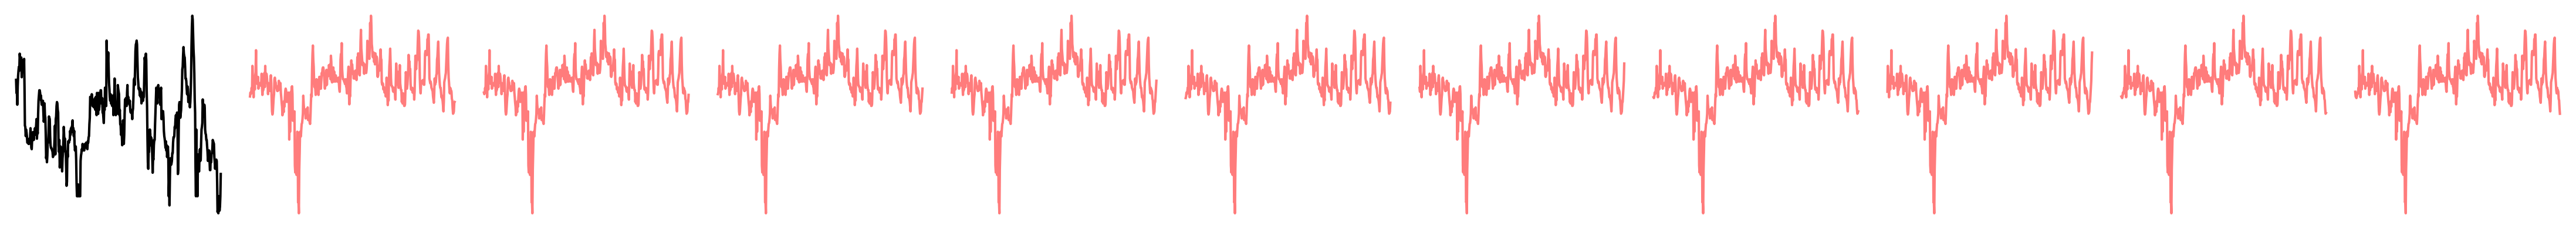

In [91]:
# 예제 사용법
idx = 300
i = 6
dataset = 'ETTh1'
k = 10
query, similar_segments, similarities, fig = retrieve_similar_segments(
    dataset_name=dataset,
    segment_length=512,
    k=k,
    var_idx=i,  # 사용할 channel 인덱스
    query_segment_idx=idx,  # Test set에서 사용할 segment 인덱스 (None이면 랜덤)
    color='red', lightness=49,M=0,
    random_seed=42
)

print(f"Query segment shape: {query.shape}")
print(f"Number of similar segments: {len(similar_segments)}")
print(f"Similarity scores: {similarities}")
plt.tight_layout()
SAVE_PATH = '/home/seunghan.lee/workspace/experiments/figures/samples'
fn = "ETTh1_0.png"
fn = os.path.join(SAVE_PATH,fn)
plt.savefig(fn, bbox_inches="tight")
plt.show()



Query segment shape: (512,)
Number of similar segments: 10
Similarity scores: [0.9769719448431577, 0.9769490643871384, 0.9769352610826347, 0.9768780204516835, 0.9768439885949163, 0.9767544816108834, 0.9767093745107519, 0.9765796692465415, 0.9765321937818554, 0.9763350082174143]


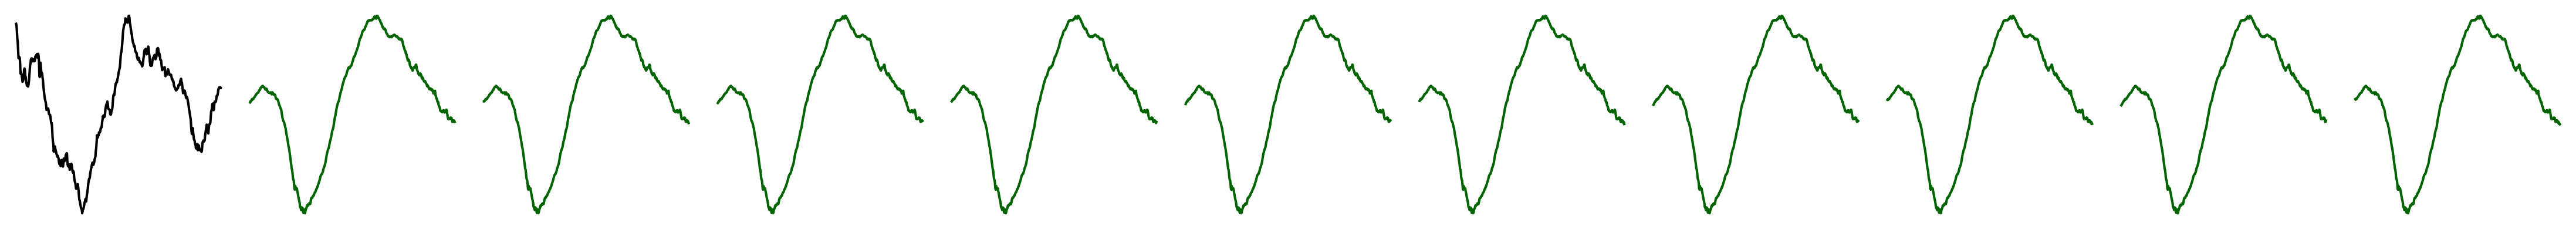

In [92]:
# 예제 사용법
idx = 100
i = 0
dataset = 'weather'
k = 10
query, similar_segments, similarities, fig = retrieve_similar_segments(
    dataset_name=dataset,
    segment_length=512,
    k=k,
    var_idx=i,  # 사용할 channel 인덱스
    query_segment_idx=idx,  # Test set에서 사용할 segment 인덱스 (None이면 랜덤)
    color='darkgreen', lightness=49,M=10,
    random_seed=42
)

print(f"Query segment shape: {query.shape}")
print(f"Number of similar segments: {len(similar_segments)}")
print(f"Similarity scores: {similarities}")
plt.tight_layout()
SAVE_PATH = '/home/seunghan.lee/workspace/experiments/figures/samples'
fn = "weather_10.png"
fn = os.path.join(SAVE_PATH,fn)
plt.savefig(fn, bbox_inches="tight")
plt.show()




Query segment shape: (512,)
Number of similar segments: 10
Similarity scores: [0.9729110120188426, 0.9728763285132191, 0.9728717394082393, 0.9728136776452919, 0.9727554690490107, 0.9727279476948716, 0.9726282504085011, 0.9725717604675674, 0.9725144009883251, 0.972393068204058]


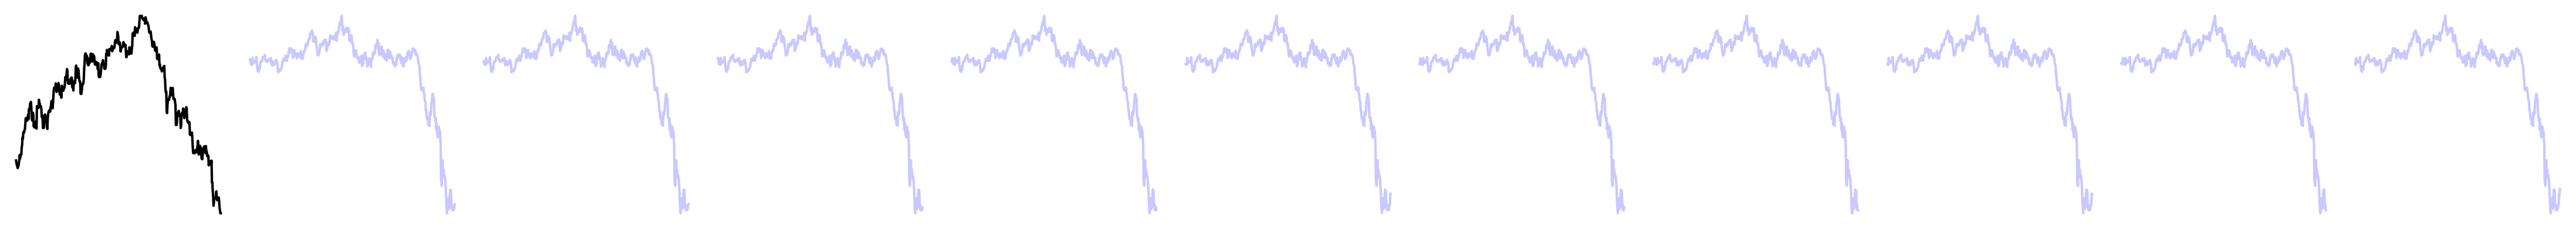

In [93]:
# 예제 사용법
idx = 300
i = 1
dataset = 'exchange_rate'
k = 10
query, similar_segments, similarities, fig = retrieve_similar_segments(
    dataset_name=dataset,
    segment_length=512,
    k=k,
    var_idx=i,  # 사용할 channel 인덱스
    query_segment_idx=idx,  # Test set에서 사용할 segment 인덱스 (None이면 랜덤)
    color='blue', lightness=79,M=0,
    random_seed=42
)

print(f"Query segment shape: {query.shape}")
print(f"Number of similar segments: {len(similar_segments)}")
print(f"Similarity scores: {similarities}")
plt.tight_layout()
SAVE_PATH = '/home/seunghan.lee/workspace/experiments/figures/samples'
fn = "exchange_0.png"
fn = os.path.join(SAVE_PATH,fn)
plt.savefig(fn, bbox_inches="tight")
plt.show()





Query segment shape: (512,)
Number of similar segments: 10
Similarity scores: [0.985419789464941, 0.9854043874931924, 0.9853782411255002, 0.9853640837937261, 0.9853140989066168, 0.9852245825527867, 0.9852075740117956, 0.9851265302270173, 0.9851141827672081, 0.9850645279623766]


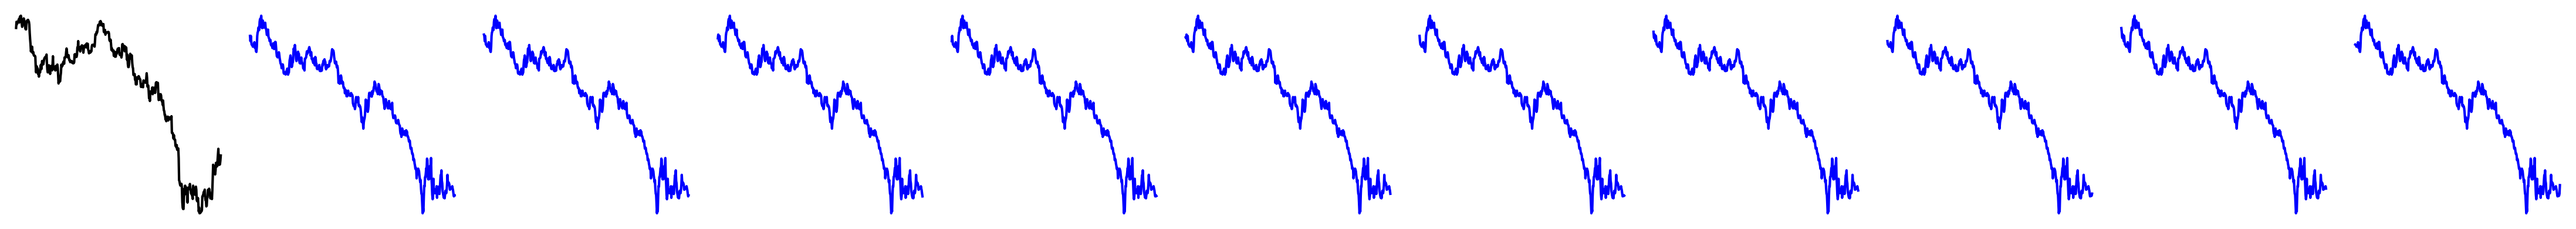

In [94]:
# 예제 사용법
idx = 400
i = 2
dataset = 'exchange_rate'
k = 10
query, similar_segments, similarities, fig = retrieve_similar_segments(
    dataset_name=dataset,
    segment_length=512,
    k=k,
    var_idx=i,  # 사용할 channel 인덱스
    query_segment_idx=idx,  # Test set에서 사용할 segment 인덱스 (None이면 랜덤)
    color='blue', lightness=79,M=10,
    random_seed=42
)

print(f"Query segment shape: {query.shape}")
print(f"Number of similar segments: {len(similar_segments)}")
print(f"Similarity scores: {similarities}")
plt.tight_layout()
SAVE_PATH = '/home/seunghan.lee/workspace/experiments/figures/samples'
fn = "exchange_10.png"
fn = os.path.join(SAVE_PATH,fn)
plt.savefig(fn, bbox_inches="tight")
plt.show()






Query segment shape: (512,)
Number of similar segments: 10
Similarity scores: [0.7385447333597716, 0.6765185018250136, 0.6764722893579683, 0.6291949344265368, 0.6285762396846952, 0.6285571267074673, 0.6284135197502791, 0.6283656342684902, 0.6283345707187331, 0.6283278329952926]


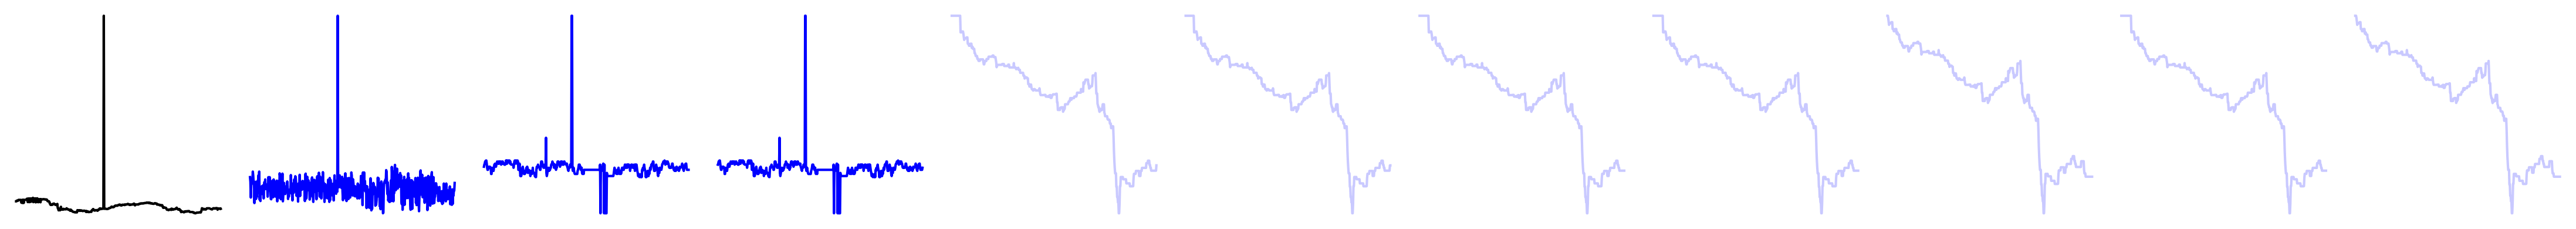

In [95]:
# 예제 사용법
idx = 400
i = 4
dataset = 'exchange_rate'
k = 10
query, similar_segments, similarities, fig = retrieve_similar_segments(
    dataset_name=dataset,
    segment_length=512,
    k=k,
    var_idx=i,  # 사용할 channel 인덱스
    query_segment_idx=idx,  # Test set에서 사용할 segment 인덱스 (None이면 랜덤)
    color='blue', lightness=79,M=3,
    random_seed=42
)

print(f"Query segment shape: {query.shape}")
print(f"Number of similar segments: {len(similar_segments)}")
print(f"Similarity scores: {similarities}")
plt.tight_layout()
SAVE_PATH = '/home/seunghan.lee/workspace/experiments/figures/samples'
fn = "exchange_3.png"
fn = os.path.join(SAVE_PATH,fn)
plt.savefig(fn, bbox_inches="tight")
plt.show()






In [ ]:
# ETTh1
# idx400, i0: 0개
# Weather:
# idx100, i1: 10개

# exchange_rate: idx300, i2 [0개]
# exchange_rate: idx400, i2 [10개]
# exchange_rate: idx400, i5 [4개]